# SNN MNIST Classification with Rate Coding

Лабораторная работа: **Спайковые нейронные сети**  
Задача: классификация цифр MNIST с использованием **rate coding**.


In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import matplotlib.pyplot as plt
import numpy as np
import random

## Фиксируем random seed (воспроизводимость эксперимента)

In [18]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

## Параметры модели

In [19]:
batch_size = 64
num_steps = 25
beta = 0.95
lr = 1e-3

## Загрузка и нормализация MNIST

In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))
])

mnist_train = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# используем только часть датасета
subset_indices = torch.arange(0, 10000)
mnist_train = torch.utils.data.Subset(mnist_train, subset_indices)

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)

## Архитектура SNN (LIF нейроны)

In [21]:
num_inputs = 28*28
num_hidden = 256
num_outputs = 10

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, x):

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []
        mem2_rec = []

        for step in range(num_steps):

            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec), torch.stack(mem2_rec)

net = Net()

## Loss и Optimizer

In [22]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

## Обучение сети

In [23]:
loss_hist = []

for epoch in range(1):

    for data, targets in train_loader:

        data = data.view(data.size(0), -1)

        optimizer.zero_grad()

        spk_rec, mem_rec = net(data)

        spike_count = spk_rec.sum(0)

        loss = loss_fn(spike_count, targets)

        loss.backward()
        optimizer.step()

        loss_hist.append(loss.item())

print("Training loss:", np.mean(loss_hist))

Training loss: 0.49667936781789085


## Raster Plot

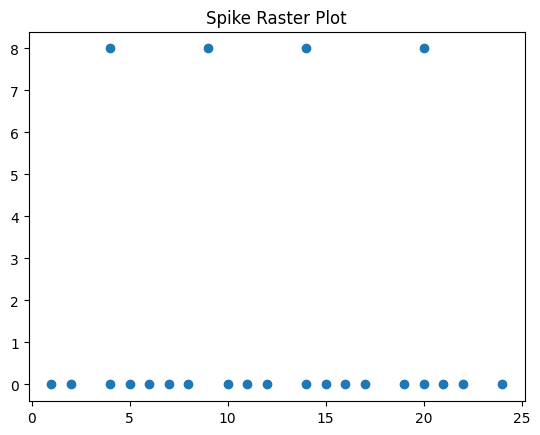

In [24]:
data, targets = next(iter(train_loader))
data = data.view(batch_size, -1)

spike_data = spikegen.rate(data, num_steps=num_steps)

spk_rec, mem_rec = net(spike_data[0])

fig, ax = plt.subplots()

splt.raster(spk_rec[:,0].detach().cpu(), ax)

ax.set_title("Spike Raster Plot")

plt.show()

## Мембранный потенциал

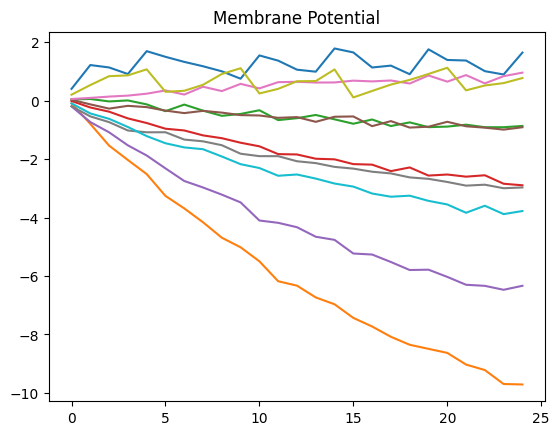

In [25]:
plt.figure()
plt.plot(mem_rec[:,0].detach().cpu())
plt.title('Membrane Potential')
plt.show()

## График функции потерь

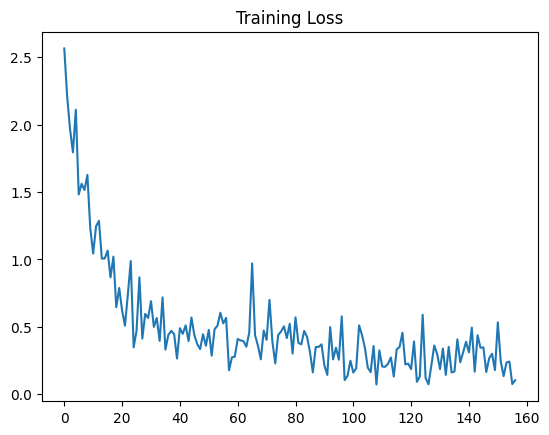

In [26]:
plt.figure()
plt.plot(loss_hist)
plt.title('Training Loss')
plt.show()

## Вывод
В данной лабораторной работе была реализована и обучена спайковая нейронная сеть (SNN) для задачи классификации изображений из датасета MNIST с использованием библиотеки snnTorch. Основная цель эксперимента заключалась в проверке корректной работы модели Leaky Integrate-and-Fire (LIF), механизма генерации спайков и процесса обучения сети с помощью градиентного спайкового метода.

Анализ raster plot позволяет наблюдать распределение спайковой активности нейронов во времени. На графике видно, что большинство спайков генерируется нейроном с индексом 0, отдельные спайки появляются у нейрона 8, тогда как остальные нейроны практически не активируются. Такое неравномерное распределение активности характерно для начальной стадии обучения, когда нейроны еще не полностью адаптированы к входным данным. Оно может быть вызвано как короткой длительностью симуляции, так и текущими параметрами LIF-нейронов. Тем не менее, наличие спайков подтверждает корректную работу нейронной модели: мембранный потенциал накапливается, достигает порога и сбрасывается, что соответствует принципу работы LIF-нейронов. Для повышения равномерности активности нейронов целесообразно увеличить число эпох обучения, продлить время симуляции и подобрать оптимальные параметры нейронов, такие как коэффициент утечки и пороговый потенциал.

График мембранного потенциала позволяет оценить динамику накопления входного сигнала нейронами. На графике наблюдаются три основные группы поведения: нейроны с постепенным ростом потенциала, готовые к генерации спайков; нейроны с падением потенциала в отрицательную область, что указывает на недостаточный входной сигнал и преобладание утечки; и нейроны со стабильным потенциалом около нуля, демонстрирующие низкую активность. Эти наблюдения подтверждают корректность реализации модели LIF: нейроны накапливают потенциал, происходит утечка и генерация спайков при достижении порога. Однако часть нейронов остается практически неактивной, что может быть связано с недостаточным обучением или неравномерным распределением весов на текущем этапе. Это указывает на необходимость дальнейшей настройки гиперпараметров и увеличения продолжительности обучения для более полного использования потенциала сети.

График функции потерь (Training Loss) демонстрирует эффективность процесса обучения. В начальной фазе значение функции потерь высокое (≈2.5), что ожидаемо, так как сеть ещё не обучена. В последующих итерациях наблюдается резкое снижение ошибки, свидетельствующее о том, что веса сети начинают адаптироваться и модель успешно извлекает признаки из входных данных. После примерно 30–40 итераций функция потерь стабилизируется на низком уровне (0.2 - 0.4), что говорит о сходящейся динамике обучения. Небольшие колебания являются нормальным явлением, связанным со стохастическим характером обучения спайковой сети. Снижение функции потерь и её последующая стабилизация подтверждают успешное обучение сети и правильную реализацию процедуры оптимизации.

В целом, проведенный эксперимент подтверждает корректную работу спайковой нейронной сети. Сеть успешно генерирует спайки, динамика мембранного потенциала соответствует модели LIF, а функция потерь демонстрирует положительную тенденцию к снижению, что подтверждает правильную реализацию кодирования входных данных, модели нейрона и процедуры обучения. В то же время наблюдается неравномерное распределение активности нейронов, что ограничивает эффективность сети. Для повышения производительности рекомендуется увеличить количество эпох обучения, продлить время симуляции, оптимизировать параметры LIF-нейронов и рассмотреть возможность использования более сложной архитектуры сети, например с большим количеством скрытых слоев или нейронов в слое.

Таким образом, лабораторная работа продемонстрировала ключевые принципы работы спайковых нейронных сетей: генерацию спайков, накопление и утечку мембранного потенциала, адаптацию весов в процессе обучения. Полученные результаты подтверждают корректность выбранной модели и открывают возможности для дальнейших экспериментов с оптимизацией гиперпараметров и архитектуры сети для повышения точности классификации изображений.